# Laboratorijske vaje    3

## 1. Prekrivanje - nadaljevanje 1. naloge iz prejšnjih vaj
Še vedno velja $F_s=8000 Hz$.
- Generirajte signal $x_4 (F_4=8880 Hz, A_4 = 0.7)$ in ga primerjajte z $x_2$.
- Analitično izpeljite gornjo ugotovitev.
- Obravnavajte še signal $x_5 (F_5=16880 Hz, A_5=0.7)$ in ga primerjajte z $x_4$ in $x_2$. Kaj ugotovite? Odgovor utemeljite.
- Določite pravilno frekvenco vzorčenja (da preprečite prekrivanje) in ponovite vzorčenje omenjenih signalov. V čem se dobljeni signali razlikujejo od prejšnjega primera? Kaj slišite, če signale predvajate v prvem in drugem primeru?

In [ ]:
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd



## 2.  Linearnost, časovna invariantnost sistemov

### Linearnost ([vir](https://angeloyeo.github.io/2022/01/11/LTI_system_en.html))
![Linearity](linearity.png)

### Časovna invariantnost ([vir](https://angeloyeo.github.io/2022/01/11/LTI_system_en.html))
![Time invariance](time_invariance.png)

- Preverite analitično ali sistem $y(n)=Ax(n)+B$ ima omenjeni lastnosti.
- Za vajo lahko ugotovite še časovno invariantnost za: $y(n)=2x(n)$, $y(n)=x^2(n)$.
- S pomočjo realnih vhodnih signalov in ustreznih odzivov testirajte omenjeni lastnosti treh neznanih sistemov (sistem1, sistem2, sistem3). Sistemi so v obliki funkcije v datoteki sistemi.py, ki jo uporabite tako: ```y = sistem1(x)```. Funkcije vnesete v okolje z ```from sistemi import sistem1, sistem2, sistem3```.
- Kako bi določili njihove odzive na enotin impulz?

In [ ]:
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from sistemi import sistem1, sistem2, sistem3


# Praktični primeri
## P1: Osnovni zvok klarineta
Preberite si [spodnje navodilo](#clarinet) za tvorbo zvoka klarineta in generirajte vsaj osnovni zvok (brez ovojnice) za dve izbrani noti. Dobljene signale zapišite v wave datoteko in ju analizirajte s programom Audacity.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io import wavefile

harmoniki = [(1, 1), (0.375, 3), (0.581, 5), (0.382, 7), (0.141, 9), (0.028, 11), (0.009, 13)]


## P2: dodajanje odmeva zvočnemu signalu
V datoteki odmev.txt se nahaja odziv na enotin impulz sistema za dodajanje odmeva vhodnemu signalu. Za LČI sisteme je značilno, da njihovo delovanje v celoti opiše t.i. odziv na enotin impulz (običajno ga označimo s $h(n)$). Vzorci $h(n)$ so namreč enaki koeficientom pred vzorci vhodnega signala v vhodno izhodnem  opisu sistema. S pomočjo zaporedja $h(n)$ in operacije konvolucije lahko za vsak vhodni signal izračunamo njemu ustrezni odziv sistema oziroma izhodni signal – to je bistvo delovanja sistema. Operacijo konvolucije zapišemo z naslednjim izrazom:

$y(n)=h(n)*x(n)=\sum_{k=-\infty}^{\infty}h(k)*x(n-k)$ 

V Pythonu to operacijo izvede vgrajena funkcija ```convolve``` iz knjižnice NumPy. Rešite naloge:
a. Uporabite podan odziv na enotin impulz na zvočnem posnetku runaway_mono.wav. Opišite postopek in rezultat.
b. Poskusite še na kakšnem drugem posnetku.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io import wavfile

h = np.loadtxt('odmev.txt', dtype=float)
Fs, x = wavfile.read('../../Data/Audio/runaway_mono.wav')


# Neobvezno, a zanimivo
## <a id="clarinet"></a> N1: Sintetizator zvoka klarineta
Na prejšnjih vajah smo spoznali način generiranja posameznih tonov, ki smo jih v nalogi neobveznega dodatka povezali v preprosto melodijo. V tej nalogi bomo obstoječ sistem nadgradili s simulacijo zvoka pihalnega instrumenta - klarineta. Osnovna značilnost vseh instrumentov je ta, da običajno njihov zvok pri izbrani noti vsebuje več različnih tonov, ki skupaj z značilnimi spremembami v amplitudi tvorijo poslušalcu precej prijetnejši zvok v primerjavi s čistim tonom.

Za praktično implementacijo aditivne sinteze bomo poskušali sintetizirati zvok klarineta (datoteka clarinet.wav). Najbolj preprosta metoda za realizacijo sinteze zvoka klarineta je »aditivna sinteza«, ki zvok klarineta ponazori z osnovno in nekaj višjeharmonskimi komponentami po naslednjem izrazu (harmonik je ton, katerega frekvenca je celi večkratnik neke osnovne frekvence – npr. 440Hz, so harmoniki 880Hz, 1320Hz, …):

$y(n)=\cos(\omega n)+0.375\cos(3\omega n)+0.581\cos(5\omega n)+0.382\cos(7\omega n)+0.141\cos(9\omega n)+0.028cos(11\omega n)+0.009\cos(13\omega n)$, 

pri čemer je $\omega=2\pi \frac{F_0}{F_s}$, $F_0$ pa osnovna frekvenca po tonski lestvici in $F_S$ frekvenca vzorčenja.

Do teh podatkov pridemo s frekvenčno analizo posnetka pravega instrumenta. 

### Ovojnica
Prav tako je potrebno omeniti tudi pojem ovojnice oziroma amplitudnega poteka posamezne odigrane note. Vsaka komponenta v zvoku instrumenta namreč nima enakomerne amplitude ves čas trajanja zvoka. Običajno ločimo 4 faze, ki se v angleščini običajno označijo kot **ADSR**:
- **Porast** (angl. Attack) amplituda komponente na začetku narašča do neke vrednosti (recimo 1)
- **Upad** (angl. Decay) amplituda se malce umiri na nižji vrednosti
- **Jedro** (angl. Sustain) del zvoka, kjer je amplituda karseda konstantna
- **Odpust** (angl. Release) amplituda komponente pada proti amplitudi 0

V datoteki envelope.sci imate na voljo funkcijo ```envelope```, ki tvori vektor z značilnim potekom amplitude pri pihalnih instrumentih, s katerim pomnožite zvok ene note klarineta in tako dosežete bolj “naraven”  zvok – z dodanim porastom, odpustom in jedrom med njima.

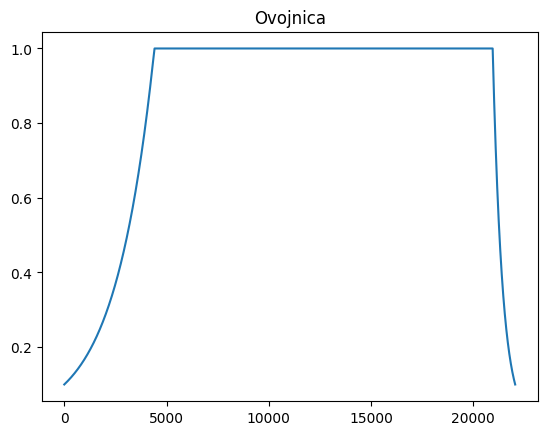

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io import wavfile
from envelope import envelope

# Primer ovojnice
ovojnica = envelope(22050, 0.2, 0.05)
plt.plot(ovojnica)
plt.title('Ovojnica')
plt.show()

### Naloge: 
1. Uporabite gornji funkciji za aditivno sintezo klarineta in ovojnice in zgenerirajte nekaj različnih tonov v tonski lestvici. 
2. Postopek za aditivno sintezo klarineta uporabite tudi v sintetizatorju melodije, ki ste jo tvorili na prejšnjih vajah s čistimi ton; te nadomestite z ustreznimi zvoki klarineta.Uporabite tudi funkcijo ovojnice.

# Ostali viri:
- http://www.phys.unsw.edu.au/music/
- http://www.animations.physics.unsw.edu.au/waves-sound/
- http://en.wikipedia.org/wiki/Note
- http://en.wikipedia.org/wiki/ADSR_envelope
- http://www.klingbeil.com/spear/